# Rip-Tide — a quantitative teardown 🔬
### Gross-vs-net Sharpe · the cost wall & break-even · turnover · the holding-period rescue · horizon & sub-period decay

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Rescue by slowing down?: Busted](https://img.shields.io/badge/Rescue_by_slowing_down%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim with its number.* The steelman: short-horizon contrarian trading is a robust, real anomaly. We confirm the apparatus captures it where it exists (synthetic control), then show that on deep liquid futures the gross premium is **statistically indistinguishable from zero** and the turnover makes the net **a `MIRAGE`** — the exact mirror of Study 31's trend result. One construction note, stated in the open: an earlier cut of this study lagged the signal twice (trading the bounce at *t+2*) and quoted net sub-period Sharpes as if gross; both are fixed here, and the verdict is earned on the corrected book.

> ⚠️ **Not investment advice.** The core executes on a synthetic Ornstein-Uhlenbeck reverting panel; the real 18-futures run is in [`../docs/results.md`](../docs/results.md), sources in [`../docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from rip_tide import data, strategy, costs, extension

# Offline synthetic control: an Ornstein-Uhlenbeck mean-reverting panel (the machinery) + a random-walk null.
# The real 18-futures verdict is in ../docs/results.md.
r, truth = data.synthetic_reversion(revert_strength=0.06, seed=32)
r0, _ = data.synthetic_reversion(revert_strength=0.0, seed=32)
print(f"synthetic control: {truth.n_markets} markets x {truth.n_days} days, revert_strength {truth.revert_strength} (null=0)")


synthetic control: 18 markets x 5040 days, revert_strength 0.06 (null=0)


## Beat 0 · Verdict

| Axis | Stamp | Why |
|---|---|---|
| **Signal** — reversion real on futures? | 🔴 `NONE` | Gross Sharpe **+0.25** but NW *t* **+1.29**; gross sub-periods **-0.00/+0.70/+0.09** — one decade carries it all. |
| **Tradability** | 🔴 `MIRAGE` | Turnover **1.41**/day ⇒ break-even **0.79 bp**; net @2 bp Sharpe **-0.39**, DD **-79%**. |
| **Rescue by slowing down?** | ⚪ `Busted` | Net Sharpe across holds 1→21d never > 0 (**-0.39→-0.30→-0.20**); the gross fades faster than the cost. |

> **In one sentence:** a real stock-market anomaly that has no counterpart on the deepest futures — gross-insignificant, and turnover-killed net — and that no amount of slowing down can save.

*(This notebook executes on the synthetic control; the real numbers are in [`../docs/results.md`](../docs/results.md).)*

## Beat 1 · The claim, precisely

Per market $i$: signal $s_{i,t} = -\mathrm{sign}\!\big(\tfrac13\sum_{L\in\{1,3,5\}}\mathrm{sign}(P_{i,t}/P_{i,t-L}-1)\big)$, known at the close of day $t$. Position $w_{i,t} = s_{i,t}\cdot\min(\sigma^\star_{\text{mkt}}/\hat\sigma_{i,t},\,c)$, then the book is scaled to a portfolio vol target, and $w_{i,t}$ earns $r_{i,t+1}$ — **one** execution lag, applied once at the book level. (Lag the signal *and* the position and a 1–5-day reversal executes at $t+2$, skipping the bounce it claims to fade — the bug the earlier cut had.) *Identical to Study 31 except for the leading minus sign.* Claim: the portfolio earns a positive premium from fading short-horizon moves. Null: i.i.d. returns ⇒ no autocorrelation to fade.

In [2]:
for label, rr in [('reverting panel', r), ('null', r0)]:
    g = strategy.summary(strategy.book_returns(rr, cost_bps=0.0))
    print(f"{label:16} gross Sharpe {g['sharpe']:+.2f}  CAGR {g['cagr']*100:+.1f}%  turnover/day {strategy.turnover(rr):.2f}")

reverting panel  gross Sharpe +3.35  CAGR +40.3%  turnover/day 1.66


null             gross Sharpe +0.18  CAGR +1.3%  turnover/day 1.58


> 💡 **In plain words.** The control has a genuine multi-day overshoot, so the book makes money gross (**3.35**); the null has none (**+0.18**). The machine can see reversion when it's there. Now point it at the real market.

## Beat 2 · So what?

Reversion is the canonical *liquidity-provision* premium: Lo–MacKinlay (1990) decompose contrarian profit into own- and cross-autocorrelation and a cross-sectional variance term; Nagel (2012) shows the payoff is the expected return on supplying liquidity, spiking when it evaporates. The pre-registered prediction, then, is that on the *deepest* instruments — where liquidity is never scarce — the premium should be smallest. Beats 4–6 test exactly that.

## Beat 3 · Pre-registered protocol

1. **Real?** `book_returns(cost_bps=0)` on control vs null and on the real tape (gross).
2. **Tradable?** `strategy.turnover`, `costs.breakeven_cost_bps`, `costs.cost_sweep`, vs `costs.long_only_basket`.
3. **Saveable?** `extension.holding_period_sweep` — net Sharpe as a function of holding period.
4. **Robust?** `extension.horizon_sweep` + `extension.subperiod_sharpe`.

**Mirage line:** break-even cost < ~1 bp (the real cost of trading ES).

## Beat 4 · The teardown

### 4a · Gross-zero on the real tape (the NONE call)

In [3]:
print('Real tape (../docs/results.md):')
print('  contrarian gross   Sharpe +0.25  CAGR +2.2%  maxDD -36%  skew -1.93')
print('  gross mean +1.11 bp/day, Newey-West t = +1.29  -- not significant')
print('  gross by sub-period: -0.00 / +0.70 / +0.09  -- one decade carries it all')
print('  contrarian net@2bp Sharpe -0.39  CAGR -4.8%  maxDD -79%')
print('  long-only basket   Sharpe +0.51  CAGR +7.6%  maxDD -55%')
# on the synthetic control the timing genuinely adds (reversion is strong there):
print('\nSynthetic control:')
print(f"  contrarian gross  Sharpe {strategy.summary(strategy.book_returns(r, cost_bps=0.0))['sharpe']:.2f}")
print(f"  long-only basket  Sharpe {strategy.summary(costs.long_only_basket(r))['sharpe']:.2f}")

Real tape (../docs/results.md):
  contrarian gross   Sharpe +0.25  CAGR +2.2%  maxDD -36%  skew -1.93
  gross mean +1.11 bp/day, Newey-West t = +1.29  -- not significant
  gross by sub-period: -0.00 / +0.70 / +0.09  -- one decade carries it all
  contrarian net@2bp Sharpe -0.39  CAGR -4.8%  maxDD -79%
  long-only basket   Sharpe +0.51  CAGR +7.6%  maxDD -55%

Synthetic control:
  contrarian gross  Sharpe 3.35


  long-only basket  Sharpe 0.02


> 💡 **In plain words.** Where overshoot is real (the control) fading it beats owning the basket; on the real, efficient futures tape the gross is a *t* of 1.3 — a number you'd see one run in five by luck — so the always-long basket wins even *before* costs. The signal is `NONE` on the thing we actually care about.

### 4b · The cost wall and the break-even (the MIRAGE call)

Real cost sweep (net Sharpe, ../docs/results.md):
  0bp +0.25   1bp -0.07   2bp -0.39   5bp -1.37   10bp -3.06
  turnover/day 1.41   break-even 0.79 bp  (ES costs ~1 bp to trade)



synthetic break-even: 8.2 bp


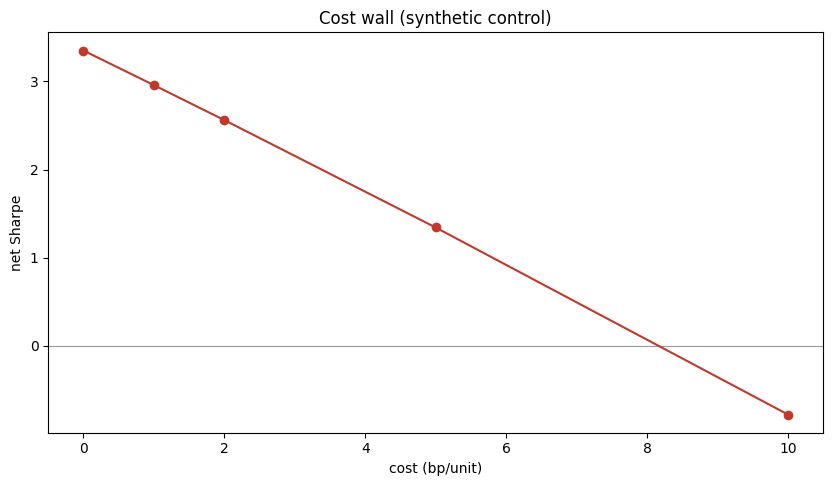

In [4]:
print('Real cost sweep (net Sharpe, ../docs/results.md):')
print('  0bp +0.25   1bp -0.07   2bp -0.39   5bp -1.37   10bp -3.06')
print(f'  turnover/day 1.41   break-even 0.79 bp  (ES costs ~1 bp to trade)')
# drawn on the synthetic, where there is an edge for cost to erode:
cs = costs.cost_sweep(r)
fig, ax = plt.subplots(); ax.axhline(0, color='#999', lw=.8)
ax.plot(cs.index, cs['sharpe'], marker='o', color='#c0392b')
ax.set_xlabel('cost (bp/unit)'); ax.set_ylabel('net Sharpe'); ax.set_title('Cost wall (synthetic control)')
print('\nsynthetic break-even:', round(costs.breakeven_cost_bps(r), 2), 'bp')

## Beat 5 · The verdict

- **`NONE`** (4a, Beat 1): real gross Sharpe +0.25 at NW *t* +1.29; control 3.35 vs null +0.18.
- **`MIRAGE`** (4b): break-even 0.79 bp < real cost; net @2 bp -0.39, DD -79%.
- **Rescue `BUSTED`** (Beat 7): net Sharpe across holds never > 0.

> **Signal `NONE` · Tradability `MIRAGE` · Rescue? `BUSTED`** — the exact mirror of Trade-Winds.

## Beat 6 · Could you trade it?

- **No.** Break-even 0.79 bp is below the real cost of trading even ES. There is no account structure — retail or institutional — that nets a positive return here.
- **Capacity is irrelevant** when the gross edge is statistically zero; you can't scale nothing.
- **Where the premium actually lives:** illiquid single stocks and crisis windows (Avramov–Chordia–Goyal 2006; Nagel 2012), not deep futures. That's the constructive lesson.

## Beat 7 · Going further

### 7a · Worked complement — the holding-period rescue ([`../docs/extension.md`](../docs/extension.md))
The book dies on turnover, so we slow it down: hold each position $h$ days and re-measure the *net* Sharpe. On the synthetic here, on the real tape in [`../docs/extension.md`](../docs/extension.md).

,gross_sharpe,net_sharpe,turnover_per_day
hold_days,,,
1,3.351,2.562,1.664
2,3.089,2.632,0.954
5,2.692,2.418,0.562
10,2.123,1.987,0.278
21,1.880,1.815,0.133


Real tape by hold (../docs/extension.md):
  gross Sharpe   1d +0.25, 2d +0.07, 5d +0.02, 10d -0.12, 21d -0.14
  net @2bp       1d -0.39, 2d -0.30, 5d -0.19, 10d -0.22, 21d -0.20 -- never > 0. BUSTED.


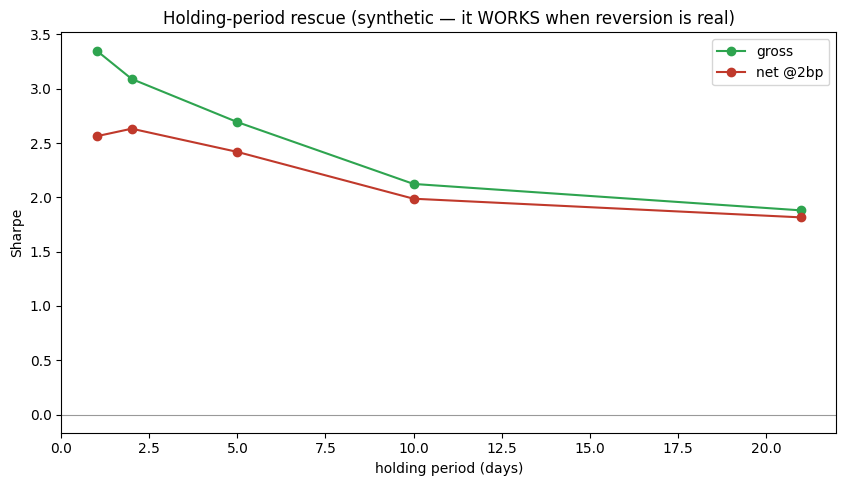

In [5]:
hp = extension.holding_period_sweep(r, holds=[1,2,5,10,21], cost_bps=2.0)
display(hp.round(3))
fig, ax = plt.subplots(); ax.axhline(0, color='#999', lw=.8)
ax.plot(hp.index, hp['gross_sharpe'], marker='o', label='gross', color='#2ea44f')
ax.plot(hp.index, hp['net_sharpe'], marker='o', label='net @2bp', color='#c0392b')
ax.set_xlabel('holding period (days)'); ax.set_ylabel('Sharpe'); ax.legend(); ax.set_title('Holding-period rescue (synthetic — it WORKS when reversion is real)')
print('Real tape by hold (../docs/extension.md):')
print('  gross Sharpe   1d +0.25, 2d +0.07, 5d +0.02, 10d -0.12, 21d -0.14')
print('  net @2bp       1d -0.39, 2d -0.30, 5d -0.19, 10d -0.22, 21d -0.20 -- never > 0. BUSTED.')

> 💡 **In plain words.** On the synthetic, slowing down keeps the net Sharpe high (>1.8 even at 21 days) because the overshoot persists for weeks. On the real tape the same knob does nothing useful — the edge and the cost vanish together. That contrast is the cleanest possible evidence that the *market*, not the method, lacks the premium.

### 7b · The horizon sweep & the honest sub-period decay
Gross and net, labelled. Not a mis-tuned lookback — no horizon clears significance gross or zero net — and the gross is confined to one epoch.

In [6]:
print('Real horizon sweep (Sharpe, gross / net @2bp, ../docs/results.md):')
print('  1d +0.42 / -0.70   3d +0.08 / -0.52   5d +0.22 / -0.21   10d -0.01 / -0.33   blend +0.25 / -0.39')
print('\nReal sub-period Sharpe (gross / net @2bp): -0.00 / -0.45,  +0.70 / -0.02,  +0.09 / -0.69')
print('all of the gross sits in 2009-2017, and even there the net rounds to zero')
print('\nSynthetic horizon sweep (where the edge IS there):')
print(extension.horizon_sweep(r).round(3).to_string())

Real horizon sweep (Sharpe, gross / net @2bp, ../docs/results.md):
  1d +0.42 / -0.70   3d +0.08 / -0.52   5d +0.22 / -0.21   10d -0.01 / -0.33   blend +0.25 / -0.39

Real sub-period Sharpe (gross / net @2bp): -0.00 / -0.45,  +0.70 / -0.02,  +0.09 / -0.69
all of the gross sits in 2009-2017, and even there the net rounds to zero

Synthetic horizon sweep (where the edge IS there):


               gross_sharpe  net_sharpe  net_cagr
lookback_days                                    
1                     1.911       0.593     0.056
3                     2.945       2.226     0.248
5                     3.630       3.073     0.361
10                    4.349       3.922     0.482
1+3+5                 3.351       2.562     0.290


**The result.** The apparatus captures reversion wherever it exists (synthetic control, every horizon, every holding period) — and on 18 deep futures finds a gross edge that fails significance at every horizon, pays in only one of three epochs, and never nets a positive Sharpe anywhere. A clean `NONE`/`MIRAGE`, and a `BUSTED` rescue. Full runs in [`../docs/results.md`](../docs/results.md) and [`../docs/extension.md`](../docs/extension.md).

### 7c · Other forks
- **Cross-sectional reversion** — relative winners within an asset class vs each market's own past.
- **Illiquid universe** — single-stock futures / small-caps, where the liquidity premium survives.
- **Crisis-conditional sizing** — trade it only when liquidity evaporates (Nagel 2012).

PRs welcome — try the cross-sectional cut, an illiquid universe, or a stress gate.